In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df=pd.read_csv('flights_sample_3m.csv')

In [3]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

# Dropping columns that may introduce data leakage.

In [4]:
cols_to_drop = [
    'DEP_TIME',
    'DEP_DELAY',
    'TAXI_OUT',
    'WHEELS_OFF',
    'WHEELS_ON',
    'TAXI_IN',
    'ARR_TIME',
    'ELAPSED_TIME',
    'AIR_TIME',
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

df = df.drop(columns=cols_to_drop)
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'CRS_ARR_TIME', 'ARR_DELAY', 'CANCELLED',
       'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'DISTANCE'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 18 columns):
 #   Column             Dtype  
---  ------             -----  
 0   FL_DATE            object 
 1   AIRLINE            object 
 2   AIRLINE_DOT        object 
 3   AIRLINE_CODE       object 
 4   DOT_CODE           int64  
 5   FL_NUMBER          int64  
 6   ORIGIN             object 
 7   ORIGIN_CITY        object 
 8   DEST               object 
 9   DEST_CITY          object 
 10  CRS_DEP_TIME       int64  
 11  CRS_ARR_TIME       int64  
 12  ARR_DELAY          float64
 13  CANCELLED          float64
 14  CANCELLATION_CODE  object 
 15  DIVERTED           float64
 16  CRS_ELAPSED_TIME   float64
 17  DISTANCE           float64
dtypes: float64(5), int64(4), object(9)
memory usage: 412.0+ MB


In [6]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,DISTANCE
count,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06,2.913802e+06,3.000000e+06,3.000000e+06,2.999986e+06,3.000000e+06
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.490561e+03,4.260858e+00,2.638000e-02,2.352000e-03,1.422758e+02,8.093616e+02
std,3.772846e+02,1.747258e+03,4.858789e+02,5.115476e+02,5.117482e+01,1.602626e-01,4.844036e-02,7.155669e+01,5.878939e+02
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,2.900000e+01
25%,1.979000e+04,1.051000e+03,9.150000e+02,1.107000e+03,-1.600000e+01,0.000000e+00,0.000000e+00,9.000000e+01,3.770000e+02
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.516000e+03,-7.000000e+00,0.000000e+00,0.000000e+00,1.250000e+02,6.510000e+02
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.919000e+03,7.000000e+00,0.000000e+00,0.000000e+00,1.720000e+02,1.046000e+03
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.934000e+03,1.000000e+00,1.000000e+00,7.050000e+02,5.812000e+03


In [7]:
df.isnull().sum()

FL_DATE                    0
AIRLINE                    0
AIRLINE_DOT                0
AIRLINE_CODE               0
DOT_CODE                   0
FL_NUMBER                  0
ORIGIN                     0
ORIGIN_CITY                0
DEST                       0
DEST_CITY                  0
CRS_DEP_TIME               0
CRS_ARR_TIME               0
ARR_DELAY              86198
CANCELLED                  0
CANCELLATION_CODE    2920860
DIVERTED                   0
CRS_ELAPSED_TIME          14
DISTANCE                   0
dtype: int64

In [8]:
df[df['CRS_ELAPSED_TIME'].isna()]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,DISTANCE
18957,2019-01-10,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,3986,CHA,"Chattanooga, TN",ORD,"Chicago, IL",800,906,NaN,1.0,C,0.0,NaN,501.0
59252,2019-01-09,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4218,ORF,"Norfolk, VA",ORD,"Chicago, IL",1320,1453,NaN,1.0,C,0.0,NaN,717.0
300154,2019-01-07,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4356,ORD,"Chicago, IL",ROC,"Rochester, NY",1400,1645,NaN,1.0,C,0.0,NaN,528.0
339033,2019-01-08,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4153,IND,"Indianapolis, IN",ORD,"Chicago, IL",1245,1259,NaN,1.0,C,0.0,NaN,177.0
515813,2019-01-11,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4078,FSD,"Sioux Falls, SD",ORD,"Chicago, IL",1815,2005,NaN,1.0,C,0.0,NaN,462.0
540351,2019-01-15,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4213,ORD,"Chicago, IL",CID,"Cedar Rapids/Iowa City, IA",1013,1129,NaN,1.0,C,0.0,NaN,196.0
980755,2019-01-08,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4427,LEX,"Lexington, KY",ORD,"Chicago, IL",1800,1839,NaN,1.0,C,0.0,NaN,323.0
1267181,2019-01-23,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4213,ORD,"Chicago, IL",CID,"Cedar Rapids/Iowa City, IA",1013,1129,NaN,1.0,C,0.0,NaN,196.0
1364752,2023-03-19,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,3480,SFO,"San Francisco, CA",LAX,"Los Angeles, CA",1020,1149,NaN,1.0,A,0.0,NaN,337.0
1936915,2019-01-11,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4273,ORD,"Chicago, IL",OKC,"Oklahoma City, OK",1020,1253,NaN,1.0,C,0.0,NaN,693.0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['ARR_DELAY']=df['ARR_DELAY'].fillna(0)
df['CRS_ELAPSED_TIME']=df['CRS_ELAPSED_TIME'].fillna(0)
df['CANCELLATION_CODE']=df['CANCELLATION_CODE'].fillna('Not Canceled')

In [11]:
df['FL_DATE']=pd.to_datetime(df['FL_DATE'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 18 columns):
 #   Column             Dtype         
---  ------             -----         
 0   FL_DATE            datetime64[ns]
 1   AIRLINE            object        
 2   AIRLINE_DOT        object        
 3   AIRLINE_CODE       object        
 4   DOT_CODE           int64         
 5   FL_NUMBER          int64         
 6   ORIGIN             object        
 7   ORIGIN_CITY        object        
 8   DEST               object        
 9   DEST_CITY          object        
 10  CRS_DEP_TIME       int64         
 11  CRS_ARR_TIME       int64         
 12  ARR_DELAY          float64       
 13  CANCELLED          float64       
 14  CANCELLATION_CODE  object        
 15  DIVERTED           float64       
 16  CRS_ELAPSED_TIME   float64       
 17  DISTANCE           float64       
dtypes: datetime64[ns](1), float64(5), int64(4), object(8)
memory usage: 412.0+ MB


In [13]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['YEAR'] = df['FL_DATE'].dt.year
df['MONTH_NUM'] = df['FL_DATE'].dt.month
df['MONTH_NAME'] = df['FL_DATE'].dt.month_name()
df['DAY_NUM'] = df['FL_DATE'].dt.dayofweek
df['DAY_NAME'] = df['FL_DATE'].dt.day_name()
df['IS_WEEKEND'] = df['DAY_NUM'].isin([5, 6]).astype(int)
df['ROUTE'] = df['ORIGIN'] + ' → ' + df['DEST']
df['IS_DELAY'] = np.where(df['ARR_DELAY']>0,1,0)

In [14]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,CRS_ELAPSED_TIME,DISTANCE,YEAR,MONTH_NUM,MONTH_NAME,DAY_NUM,DAY_NAME,IS_WEEKEND,ROUTE,IS_DELAY
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,186.0,1065.0,2019,1,January,2,Wednesday,0,FLL → EWR,0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,235.0,1399.0,2022,11,November,5,Saturday,1,MSP → SEA,0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,118.0,680.0,2022,7,July,4,Friday,0,DEN → MSP,0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,260.0,1589.0,2023,3,March,0,Monday,0,MSP → SFO,1
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,181.0,985.0,2020,2,February,6,Sunday,1,MCO → DFW,0


In [15]:
airline_summary=df.groupby('AIRLINE',as_index=False).agg(Total_flight=('AIRLINE','count'),Total_Delays=('IS_DELAY','sum'))
airline_summary['Delays %']=round(airline_summary['Total_Delays']/airline_summary['Total_flight'],2)*100
airline_summary.sort_values('Delays %',ascending=False)

,AIRLINE,Total_flight,Total_Delays,Delays %
1,Allegiant Air,52738,21998,42.0
8,Hawaiian Airlines Inc.,32114,12884,40.0
7,Frontier Airlines Inc.,64466,25928,40.0
10,JetBlue Airways,112844,44564,39.0
16,Spirit Air Lines,95711,35292,37.0
0,Alaska Airlines Inc.,100467,35856,36.0
15,Southwest Airlines Co.,576470,201632,35.0
9,Horizon Air,20634,7074,34.0
2,American Airlines Inc.,383106,131477,34.0
6,ExpressJet Airlines LLC d/b/a aha!,19082,6435,34.0


In [16]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Total Flights
fig.add_trace(
    go.Bar(
        x=airline_summary['AIRLINE'],
        y=airline_summary['Total_flight'],
        name='Total Flights'
    ),
    secondary_y=False
)

# Total Delays
fig.add_trace(
    go.Bar(
        x=airline_summary['AIRLINE'],
        y=airline_summary['Total_Delays'],
        name='Total Delays'
    ),
    secondary_y=False
)

# Delay %
fig.add_trace(
    go.Scatter(
        x=airline_summary['AIRLINE'],
        y=airline_summary['Delays %'],
        mode='lines+markers',
        name='Delay %'
    ),
    secondary_y=True
)

fig.update_layout(
    title='Airline Delay Analysis',
    xaxis_title='Airline',
    barmode='group',
    height=600
)

fig.update_yaxes(title_text='Flights / Delays', secondary_y=False)
fig.update_yaxes(title_text='Delay %', secondary_y=True)

fig.show()

In [17]:
Route_summary=df.groupby('ROUTE',as_index=False).agg(Total_flight=('AIRLINE','count'),Total_Delays=('IS_DELAY','sum'))
Route_summary['Delays %']=round(Route_summary['Total_Delays']/Route_summary['Total_flight'],2)*100
Route_summary=Route_summary[Route_summary['Total_flight'] > Route_summary['Total_flight'].mean()]
Route_summary.sort_values('Delays %',ascending=False).head(10)

,ROUTE,Total_flight,Total_Delays,Delays %
5114,OGG → LIH,450,243,54.0
4271,MCO → BQN,389,212,54.0
1811,DEN → BHM,410,205,50.0
914,BQN → MCO,390,196,50.0
3792,LAS → MSY,413,204,49.0
3747,LAS → FLL,445,217,49.0
2169,DFW → SMF,738,358,49.0
3758,LAS → HNL,529,252,48.0
7046,SJU → EWR,949,455,48.0
4355,MCO → SJU,2608,1262,48.0


In [18]:
Route_summary['Score'] = (
    Route_summary['Delays %']
    * np.log(Route_summary['Total_flight'])
)

Route_summary=Route_summary.sort_values(
    'Score',
    ascending=False
).head(10)
Route_summary

,ROUTE,Total_flight,Total_Delays,Delays %,Score
4355,MCO → SJU,2608,1262,48.0,377.584268
4291,MCO → EWR,2853,1265,44.0,350.069559
5108,OGG → HNL,4656,1851,40.0,337.836480
2094,DFW → LAS,2401,1041,43.0,334.696546
2107,DFW → MCO,1990,870,44.0,334.219156
3816,LAS → SAN,2268,967,43.0,332.246108
2002,DFW → AUS,1872,821,44.0,331.529557
5114,OGG → LIH,450,243,54.0,329.899369
7046,SJU → EWR,949,455,48.0,329.059622
4600,MIA → LAX,1212,561,46.0,326.601250


In [19]:
fig = px.bar(
    Route_summary,
    x='ROUTE',
    y='Delays %',
    title='Top 10 Routes by Delay Percentage'
)

fig.show()

In [20]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,CRS_ELAPSED_TIME,DISTANCE,YEAR,MONTH_NUM,MONTH_NAME,DAY_NUM,DAY_NAME,IS_WEEKEND,ROUTE,IS_DELAY
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,186.0,1065.0,2019,1,January,2,Wednesday,0,FLL → EWR,0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,235.0,1399.0,2022,11,November,5,Saturday,1,MSP → SEA,0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,118.0,680.0,2022,7,July,4,Friday,0,DEN → MSP,0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,260.0,1589.0,2023,3,March,0,Monday,0,MSP → SFO,1
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,181.0,985.0,2020,2,February,6,Sunday,1,MCO → DFW,0


In [21]:
Time = df.groupby(
    ['YEAR','MONTH_NUM'],
    as_index=False
).agg(
    Total_flight=('AIRLINE','count'),
    Total_Delays=('IS_DELAY','sum')
)
Time['Delays %']=round(Time['Total_Delays']/Time['Total_flight'],2)*100
Time

,YEAR,MONTH_NUM,Total_flight,Total_Delays,Delays %
0,2019,1,59412,19712,33.0
1,2019,2,54565,21025,39.0
2,2019,3,64894,20813,32.0
3,2019,4,62080,19778,32.0
4,2019,5,64966,22694,35.0
5,2019,6,64777,26005,40.0
6,2019,7,67213,23519,35.0
7,2019,8,67469,23479,35.0
8,2019,9,61987,16509,27.0
9,2019,10,64869,20552,32.0


In [22]:
pivot=Time.pivot_table(index='YEAR',columns='MONTH_NUM',values='Delays %',aggfunc='mean')
pivot

MONTH_NUM,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
2019,33.0,39.0,32.0,32.0,35.0,40.0,35.0,35.0,27.0,32.0,29.0,37.0
2020,26.0,28.0,18.0,7.0,12.0,17.0,20.0,19.0,17.0,21.0,20.0,27.0
2021,22.0,27.0,23.0,24.0,28.0,40.0,42.0,38.0,28.0,34.0,31.0,38.0
2022,31.0,33.0,37.0,39.0,37.0,40.0,39.0,37.0,31.0,32.0,36.0,42.0
2023,38.0,34.0,42.0,39.0,33.0,43.0,44.0,37.0,NaN,NaN,NaN,NaN


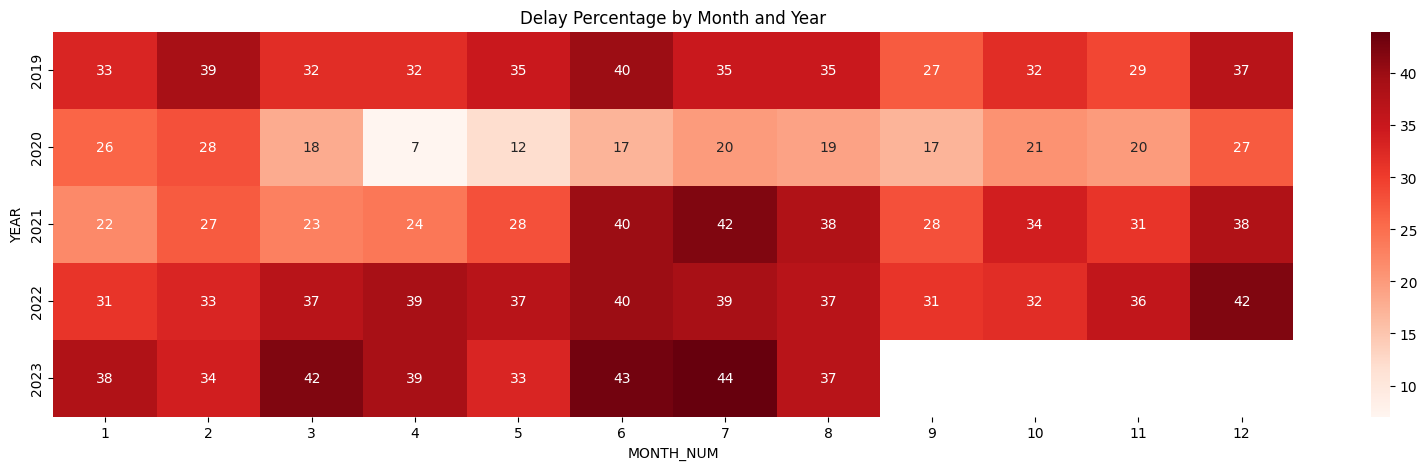

In [23]:
plt.figure(figsize=(20,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='Reds'
)

plt.title('Delay Percentage by Month and Year')
plt.show()

In [24]:
month = df.groupby(
    ['MONTH_NUM'],
    as_index=False
).agg(
    Total_flight=('AIRLINE','count'),
    Total_Delays=('IS_DELAY','sum')
)
month['Delays %']=round(Time['Total_Delays']/Time['Total_flight'],2)*100
month

,MONTH_NUM,Total_flight,Total_Delays,Delays %
0,1,268702,82137,33.0
1,2,248497,80510,39.0
2,3,293099,89194,32.0
3,4,253917,77330,32.0
4,5,252530,80598,35.0
5,6,261136,101234,40.0
6,7,284968,105672,35.0
7,8,287104,98308,35.0
8,9,206928,55349,27.0
9,10,216790,66196,32.0


In [25]:
fig = px.bar(
    month,
    x='MONTH_NUM',
    y='Delays %',
    title='Delay Percentage by Month'
)

fig.show()

In [26]:
day = df.groupby(
    ['DAY_NAME'],
    as_index=False
).agg(
    Total_flight=('AIRLINE','count'),
    Total_Delays=('IS_DELAY','sum')
)
day['Delays %']=round(Time['Total_Delays']/Time['Total_flight'],2)*100
day

,DAY_NAME,Total_flight,Total_Delays,Delays %
0,Friday,446292,156518,33.0
1,Monday,446600,146304,39.0
2,Saturday,384223,120185,32.0
3,Sunday,436561,147087,32.0
4,Thursday,446925,153365,35.0
5,Tuesday,416562,123866,40.0
6,Wednesday,422837,130822,35.0


In [27]:
fig = px.bar(
    day,
    x='DAY_NAME',
    y='Delays %',
    title='Delay Percentage by Month'
)

fig.show()

In [28]:
fig = px.line(
    Time.sort_values(['YEAR', 'MONTH_NUM']),
    x='MONTH_NUM',
    y='Delays %',
    color='YEAR',
    markers=True,
    title='Delay Percentage by Month and Year'
)

fig.show()

In [29]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'CRS_ARR_TIME', 'ARR_DELAY', 'CANCELLED',
       'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'DISTANCE', 'YEAR',
       'MONTH_NUM', 'MONTH_NAME', 'DAY_NUM', 'DAY_NAME', 'IS_WEEKEND', 'ROUTE',
       'IS_DELAY'],
      dtype='object')

In [30]:
df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100

df = df[
    (df['CANCELLED'] == 0) &
    (df['DIVERTED'] == 0)
]

Clean_df = df.sample(
    n=500000,
    random_state=42
).reset_index(drop=True)

columns_to_drop = [
    'FL_DATE',
    'MONTH_NAME',
    'DAY_NAME',
    'ROUTE',
    'IS_DELAY',
    'YEAR',
    'CANCELLED',
    'CANCELLATION_CODE',
    'DIVERTED',
    'CRS_ARR_TIME',
    'CRS_DEP_TIME'
]




In [31]:
df.to_parquet('Clean_flight_Data.parquet', index=False)